# SEMIR End-to-End: LiTS Tumor Segmentation

**Goal**: Replace GT CSV files in the VKG pipeline with SEMIR graph-minor-based tumor segmentation.

**Pipeline**:  
`Raw CT → HU Window → Graph Minor (contraction + deletion) → Feature Extraction → GINE Classification → Voxel Lifting → Dice Evaluation`

**Data**: LiTS (Liver Tumor Segmentation) — 131 volumes as `.npy`, labels: 0=background, 1=liver, 2=tumor.

**For Luke**: The GINE code is in Cell 6. If the architecture or training loop needs changes, that's the place.

## 1. Setup & Data Loading

In [1]:
import os, sys, re, time, json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Add src to path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

DATA_ROOT = "/scratch/ud3d4/acm_data/Data"

def discover_lits_volumes():
    """Find all LiTS volumes that have both CT and segmentation."""
    ct_dir = os.path.join(DATA_ROOT, "ct")
    ids = []
    for f in sorted(os.listdir(ct_dir)):
        m = re.match(r"volume-(\d+)\.npy", f)
        if m:
            vid = int(m.group(1))
            seg_path = os.path.join(DATA_ROOT, "seg", f"segmentation-{vid}.npy")
            if os.path.exists(seg_path):
                ids.append(vid)
    return sorted(ids)

def load_lits_case(vol_id):
    ct = np.load(os.path.join(DATA_ROOT, "ct", f"volume-{vol_id}.npy")).astype(np.float32)
    seg = np.load(os.path.join(DATA_ROOT, "seg", f"segmentation-{vol_id}.npy")).astype(np.int32)
    return ct, seg

def hu_window(vol, hu_min=0, hu_max=200):
    """Liver-specific HU window [0, 200]. Maximizes liver-tumor contrast:
    liver ~60-80 HU -> 0.30-0.40 normalized, tumor ~30-50 HU -> 0.15-0.25.
    Gap = ~0.10-0.15 (vs 0.05-0.07 with wide [-150, 250] window)."""
    vol = np.clip(vol, hu_min, hu_max)
    return (vol - hu_min) / (hu_max - hu_min)

# Discover and split
all_ids = discover_lits_volumes()
print(f"Found {len(all_ids)} LiTS volumes")

np.random.seed(42)
perm = np.random.permutation(all_ids)
n = len(perm)
n_train = max(3, int(0.7 * n))
n_val = max(1, int(0.15 * n))

train_ids = sorted(perm[:n_train].tolist())
val_ids   = sorted(perm[n_train:n_train + n_val].tolist())
test_ids  = sorted(perm[n_train + n_val:].tolist())
all_ordered = train_ids + val_ids + test_ids

print(f"Split: {len(train_ids)} train / {len(val_ids)} val / {len(test_ids)} test")

Found 131 LiTS volumes
Split: 91 train / 19 val / 21 test


In [2]:
# Load a subset (set N_CASES to limit for quick runs)
N_CASES = len(all_ordered)  # change to e.g. 10 for quick testing

volumes, segs, case_ids = [], [], []
for vid in all_ordered[:N_CASES]:
    ct, seg = load_lits_case(vid)
    ct = hu_window(ct)
    volumes.append(ct)
    segs.append(seg)
    case_ids.append(f"lits_volume_{vid}")
    
    n_liver = int((seg == 1).sum())
    n_tumor = int((seg == 2).sum())
    print(f"  vol-{vid}: shape={ct.shape}  liver={n_liver:,}  "
          f"tumor={n_tumor:,}  coverage={n_tumor/max(n_liver,1)*100:.2f}%")

n_train_total = min(len(train_ids), N_CASES)
n_val_total = min(len(val_ids), max(0, N_CASES - len(train_ids)))
print(f"\nLoaded {len(volumes)} volumes  (train={n_train_total}, val={n_val_total})")

  vol-0: shape=(28, 256, 256)  liver=138,634  tumor=704  coverage=0.51%
  vol-3: shape=(168, 256, 256)  liver=819,243  tumor=728  coverage=0.09%
  vol-4: shape=(249, 256, 256)  liver=833,817  tumor=384,871  coverage=46.16%
  vol-5: shape=(175, 256, 256)  liver=482,747  tumor=148  coverage=0.03%
  vol-6: shape=(185, 256, 256)  liver=616,505  tumor=8,327  coverage=1.35%
  vol-7: shape=(176, 256, 256)  liver=764,760  tumor=8,467  coverage=1.11%
  vol-8: shape=(178, 256, 256)  liver=661,930  tumor=5,472  coverage=0.83%
  vol-9: shape=(171, 256, 256)  liver=575,440  tumor=5,832  coverage=1.01%
  vol-10: shape=(180, 256, 256)  liver=720,865  tumor=6,391  coverage=0.89%
  vol-11: shape=(166, 256, 256)  liver=821,333  tumor=2,831  coverage=0.34%
  vol-12: shape=(188, 256, 256)  liver=1,058,620  tumor=214  coverage=0.02%
  vol-13: shape=(140, 256, 256)  liver=473,760  tumor=6,269  coverage=1.32%
  vol-15: shape=(132, 256, 256)  liver=815,340  tumor=243  coverage=0.03%
  vol-16: shape=(186, 256,

## 2. Graph Minor Construction

Three parameterized operations (SEMIR paper Section 3.2):

1. **Edge contraction (ψ)** — merge adjacent voxels/supernodes with intensity diff ≤ ψ.  
   We have two backends:
   - **C flood-fill** (`semir_minor.so`): compares each neighbor against the *seed* voxel's intensity → prevents transitive drift. This is closest to the paper's binary tensor.
   - **Adaptive watershed** (Python fallback): coarse watershed + refinement in heterogeneous regions.

2. **Node deletion (β)** — remove supernodes with size outside [β_min, β_max] or mean intensity outside [m_min, m_max].

3. **Edge deletion (α)** — sever edges where supernode mean-intensity diff > α.

Output: a label volume where each voxel maps to a supernode ID (0 = deleted).

In [3]:
from semir.graph_minor import build_graph_minor

# Optimized parameters from sweep (oracle Dice 0.59 with [0,200] window)
# Balance: psi=0.06 + beta=10 gives ~24K SN + 64K edges — tractable for GNN
# Tighter psi prevents liver-tumor merging; alpha=psi keeps edges consistent
PARAMS = {
    "psi": 0.06,        # contraction threshold (tighter = less liver-tumor merging)
    "alpha": 0.06,      # edge deletion threshold (= psi for consistency)
    "beta_min": 10,     # minimum supernode size (voxels)
    "beta_max": 500000, # maximum supernode size
    "m_min": 0.0,       # minimum mean intensity
    "m_max": 1.0,       # maximum mean intensity
}

# Build graph minors for all volumes
minors = []
for vol, seg, cid in zip(volumes, segs, case_ids):
    t0 = time.time()
    gm = build_graph_minor(vol, **PARAMS)
    dt = time.time() - t0
    minors.append(gm)
    
    s = gm["stats"]
    print(f"  {cid}: {s['n_voxels']:>10,} voxels -> {s['n_supernodes_after_deletion']:>6,} SN  "
          f"({s['compression_ratio']:,.0f}x)  edges={s['n_edges']:,}  "
          f"full_edges={len(gm['full_adjacency']):,}  method={s['method']}  {dt:.1f}s")

  lits_volume_0:  1,835,008 voxels ->  2,355 SN  (779x)  edges=459  full_edges=5,685  method=c  0.3s
  lits_volume_3: 11,010,048 voxels -> 20,808 SN  (529x)  edges=5,240  full_edges=52,588  method=c  2.4s
  lits_volume_4: 16,318,464 voxels -> 20,248 SN  (806x)  edges=5,548  full_edges=50,277  method=c  2.9s
  lits_volume_5: 11,468,800 voxels -> 13,296 SN  (863x)  edges=3,968  full_edges=30,818  method=c  1.8s
  lits_volume_6: 12,124,160 voxels -> 14,646 SN  (828x)  edges=4,488  full_edges=34,638  method=c  2.1s
  lits_volume_7: 11,534,336 voxels -> 21,746 SN  (530x)  edges=5,943  full_edges=54,659  method=c  2.2s
  lits_volume_8: 11,665,408 voxels -> 16,939 SN  (689x)  edges=4,754  full_edges=43,274  method=c  2.1s
  lits_volume_9: 11,206,656 voxels -> 16,291 SN  (688x)  edges=4,430  full_edges=42,363  method=c  2.0s
  lits_volume_10: 11,796,480 voxels -> 19,430 SN  (607x)  edges=5,617  full_edges=51,237  method=c  2.3s
  lits_volume_11: 10,878,976 voxels -> 29,580 SN  (368x)  edges=8,

### 2b. Oracle Analysis — Quality Ceiling

Before training the GINE, check: **how good could segmentation be** if the GINE were perfect?

For each volume, we label supernodes as "tumor" if >10% of their voxels overlap with GT tumor, then measure voxel-level Dice. This is the quality ceiling — any GINE Dice score below this means the classifier is the bottleneck, not the graph minor.

In [4]:
def oracle_dice(gm, seg):
    """Dice if we perfectly identify tumor supernodes using GT labels."""
    labels = gm["labels"]
    max_label = int(labels.max())
    if max_label == 0:
        return 0.0, 0, 0, 0
    
    flat_labels = labels.ravel()
    flat_gt = (seg.ravel() == 2).astype(np.float64)
    
    tumor_counts = np.bincount(flat_labels, weights=flat_gt, minlength=max_label + 1)
    total_counts = np.bincount(flat_labels, minlength=max_label + 1)
    safe = np.where(total_counts > 0, total_counts, 1)
    overlap = tumor_counts / safe
    
    # Supernodes with >10% tumor overlap → predicted as tumor
    is_tumor = overlap > 0.1
    is_tumor[0] = False  # label 0 = deleted
    
    # Build prediction mask via LUT
    pred_lut = is_tumor.astype(np.int32)
    pred_mask = pred_lut[flat_labels]
    gt_mask = flat_gt.astype(np.int32)
    
    tp = int((pred_mask & gt_mask).sum())
    fp = int(pred_mask.sum()) - tp
    fn = int(gt_mask.sum()) - tp
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    
    n_tumor_sn = int(is_tumor.sum())
    # Voxels in deleted supernodes that were tumor
    deleted_tumor = int(flat_gt[flat_labels == 0].sum())
    
    return dice, n_tumor_sn, deleted_tumor, int(gt_mask.sum())

oracle_results = []
for gm, seg, cid in zip(minors, segs, case_ids):
    dice, n_tsn, del_t, gt_t = oracle_dice(gm, seg)
    oracle_results.append({"case": cid, "dice": dice, "tumor_sn": n_tsn,
                           "deleted_tumor_vox": del_t, "gt_tumor_vox": gt_t})
    del_pct = del_t / max(gt_t, 1) * 100
    print(f"  {cid}: oracle_dice={dice:.4f}  tumor_SN={n_tsn}  "
          f"deleted_tumor={del_t:,}/{gt_t:,} ({del_pct:.1f}% lost)")

mean_oracle = np.mean([r["dice"] for r in oracle_results])
mean_del = np.mean([r["deleted_tumor_vox"] / max(r["gt_tumor_vox"], 1) * 100 for r in oracle_results])
print(f"\nMean oracle Dice (quality ceiling): {mean_oracle:.4f}")
print(f"Mean deletion loss: {mean_del:.1f}%")
print(f"--> If oracle << 1.0, graph minor loses tumor at Stage 1 (contraction/deletion issue).")
print(f"--> If oracle is high but GINE Dice is low, classifier is the bottleneck.")

  lits_volume_0: oracle_dice=0.5134  tumor_SN=19  deleted_tumor=205/704 (29.1% lost)
  lits_volume_3: oracle_dice=0.6119  tumor_SN=11  deleted_tumor=135/728 (18.5% lost)
  lits_volume_4: oracle_dice=0.7242  tumor_SN=1513  deleted_tumor=102,035/384,871 (26.5% lost)
  lits_volume_5: oracle_dice=0.1615  tumor_SN=1  deleted_tumor=25/148 (16.9% lost)
  lits_volume_6: oracle_dice=0.6846  tumor_SN=72  deleted_tumor=1,869/8,327 (22.4% lost)
  lits_volume_7: oracle_dice=0.7004  tumor_SN=84  deleted_tumor=2,208/8,467 (26.1% lost)
  lits_volume_8: oracle_dice=0.6796  tumor_SN=31  deleted_tumor=1,204/5,472 (22.0% lost)
  lits_volume_9: oracle_dice=0.6370  tumor_SN=51  deleted_tumor=1,374/5,832 (23.6% lost)
  lits_volume_10: oracle_dice=0.6742  tumor_SN=71  deleted_tumor=1,650/6,391 (25.8% lost)
  lits_volume_11: oracle_dice=0.4547  tumor_SN=40  deleted_tumor=764/2,831 (27.0% lost)
  lits_volume_12: oracle_dice=0.4382  tumor_SN=2  deleted_tumor=133/214 (62.1% lost)
  lits_volume_13: oracle_dice=0.1

## 3. Feature Extraction → PyG Graphs

Per-supernode features (7 node features, paper Section 3.2):

| Feature | Formula | What it captures |
|---|---|---|
| `volume` | voxel count | size |
| `boundary_length` | boundary voxel count | surface area proxy |
| `compactness` | 36πV²/A³ | roundness (1.0 = sphere) |
| `elongation` | λ_max/λ_min (PCA) | shape stretch |
| `dominant_axis` | max eigenvalue | principal direction magnitude |
| `mean_intensity` | mean HU | tissue type |
| `intensity_std` | std HU | heterogeneity |

Per-edge features (4):
- `log_volume_ratio`, `intensity_diff_norm`, `distance_norm`, `orientation_cos`

In [5]:
from semir.features import extract_node_features, extract_edge_features, build_pyg_graph

pyg_graphs = []
all_node_feats = []
all_edge_feats = []

for gm, vol, seg, cid in zip(minors, volumes, segs, case_ids):
    nf = extract_node_features(gm["labels"], vol)
    # Use FULL adjacency for GNN (alpha-filtered is too sparse for message passing)
    adj_for_gnn = gm.get("full_adjacency", gm["adjacency"])
    ef = extract_edge_features(gm["labels"], vol, adj_for_gnn, nf)
    data, mapping = build_pyg_graph(nf, ef, gm["labels"], gt_seg=seg)
    
    pyg_graphs.append(data)
    all_node_feats.append(nf)
    all_edge_feats.append(ef)
    
    n_tu = int((data.y == 1).sum()) if hasattr(data, 'y') else 0
    n_bg = int((data.y == 0).sum()) if hasattr(data, 'y') else 0
    print(f"  {cid}: {data.num_nodes:,} nodes ({n_tu} tumor, {n_bg:,} bg), "
          f"{data.num_edges:,} edges, x.shape={data.x.shape}")

# Quick look at class balance
total_tumor = sum(int((g.y == 1).sum()) for g in pyg_graphs)
total_bg = sum(int((g.y == 0).sum()) for g in pyg_graphs)
print(f"\nTotal supernodes: {total_tumor + total_bg:,}  "
      f"(tumor={total_tumor:,}, bg={total_bg:,}, ratio=1:{total_bg/max(total_tumor,1):.0f})")

/home/ud3d4/.conda/envs/llmft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  lits_volume_0: 2,355 nodes (19 tumor, 2,336 bg), 11,370 edges, x.shape=torch.Size([2355, 7])
  lits_volume_3: 20,808 nodes (11 tumor, 20,797 bg), 105,176 edges, x.shape=torch.Size([20808, 7])
  lits_volume_4: 20,248 nodes (1513 tumor, 18,735 bg), 100,554 edges, x.shape=torch.Size([20248, 7])
  lits_volume_5: 13,296 nodes (1 tumor, 13,295 bg), 61,636 edges, x.shape=torch.Size([13296, 7])
  lits_volume_6: 14,646 nodes (72 tumor, 14,574 bg), 69,276 edges, x.shape=torch.Size([14646, 7])
  lits_volume_7: 21,746 nodes (84 tumor, 21,662 bg), 109,318 edges, x.shape=torch.Size([21746, 7])
  lits_volume_8: 16,939 nodes (31 tumor, 16,908 bg), 86,548 edges, x.shape=torch.Size([16939, 7])
  lits_volume_9: 16,291 nodes (51 tumor, 16,240 bg), 84,726 edges, x.shape=torch.Size([16291, 7])
  lits_volume_10: 19,430 nodes (71 tumor, 19,359 bg), 102,474 edges, x.shape=torch.Size([19430, 7])
  lits_volume_11: 29,580 nodes (40 tumor, 29,540 bg), 162,986 edges, x.shape=torch.Size([29580, 7])
  lits_volume_1

## 4. Visualize One Volume

Show a mid-slice with: CT, GT segmentation, supernode boundaries, and GT-labeled tumor supernodes.

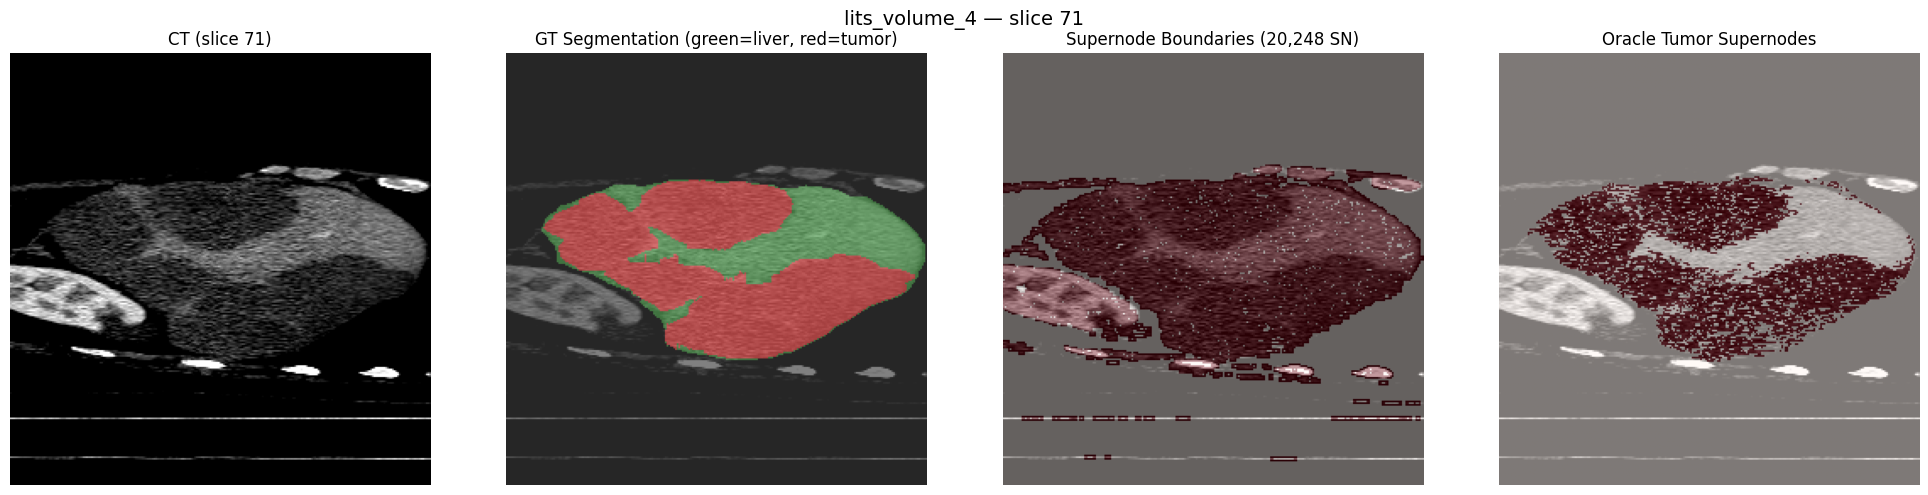

In [6]:
# Pick first volume with a decent tumor
viz_idx = 0
for i, seg in enumerate(segs):
    if (seg == 2).sum() > 1000:
        viz_idx = i
        break

vol_viz = volumes[viz_idx]
seg_viz = segs[viz_idx]
gm_viz = minors[viz_idx]
labels_viz = gm_viz["labels"]

# Find slice with most tumor voxels
tumor_per_slice = (seg_viz == 2).sum(axis=(0, 1))
mid_slice = int(np.argmax(tumor_per_slice))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. CT
axes[0].imshow(vol_viz[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[0].set_title(f"CT (slice {mid_slice})")

# 2. GT segmentation
seg_slice = seg_viz[:, :, mid_slice].T
seg_rgb = np.zeros((*seg_slice.shape, 3))
seg_rgb[seg_slice == 1] = [0.2, 0.6, 0.2]  # liver = green
seg_rgb[seg_slice == 2] = [1.0, 0.2, 0.2]  # tumor = red
axes[1].imshow(vol_viz[:, :, mid_slice].T, cmap="gray", origin="lower", alpha=0.7)
axes[1].imshow(seg_rgb, origin="lower", alpha=0.5)
axes[1].set_title("GT Segmentation (green=liver, red=tumor)")

# 3. Supernode boundaries
from scipy.ndimage import sobel as nd_sobel
lab_slice = labels_viz[:, :, mid_slice].astype(np.float64)
boundary = np.abs(nd_sobel(lab_slice, axis=0)) + np.abs(nd_sobel(lab_slice, axis=1)) > 0
axes[2].imshow(vol_viz[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[2].imshow(boundary.T, cmap="Reds", origin="lower", alpha=0.4)
axes[2].set_title(f"Supernode Boundaries ({gm_viz['n_supernodes']:,} SN)")

# 4. Oracle tumor supernodes
nf_viz = all_node_feats[viz_idx]
flat_l = labels_viz.ravel()
flat_gt = (seg_viz.ravel() == 2).astype(np.float64)
max_id = int(labels_viz.max())
tc = np.bincount(flat_l, weights=flat_gt, minlength=max_id + 1)
ttc = np.bincount(flat_l, minlength=max_id + 1)
safe = np.where(ttc > 0, ttc, 1)
ovlp = tc / safe
oracle_lut = (ovlp > 0.1).astype(np.int32)
oracle_lut[0] = 0
oracle_mask = oracle_lut[labels_viz[:, :, mid_slice]]

axes[3].imshow(vol_viz[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[3].imshow(oracle_mask.T, cmap="Reds", origin="lower", alpha=0.5)
axes[3].set_title("Oracle Tumor Supernodes")

for ax in axes:
    ax.axis("off")
plt.suptitle(f"{case_ids[viz_idx]} — slice {mid_slice}", fontsize=14)
plt.tight_layout()
plt.show()

## 5. GINE Architecture

3-layer Graph Isomorphism Network with Edge features (paper Section 3.2, Appendix F).

**Luke — this is the part to review.** Current architecture:
- 3 × GINEConv layers, hidden_dim=128
- Edge features projected from 4 → 128 dims
- Classifier: Linear(128→64) → ReLU → Dropout(0.3) → Linear(64→2)
- Training: Adam(lr=1e-3), weighted CrossEntropy, early stopping on val Dice (patience=10)

Known issues:
- Extreme class imbalance (tumor supernodes are ~1-5% of total)
- Many graphs have few/no edges after deletion → isolated nodes with no message passing
- Self-loops are added for isolated nodes to keep GINEConv happy

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, BatchNorm

class SEMIRClassifier(nn.Module):
    """3-layer GINE for supernode-level tumor classification."""
    
    def __init__(self, node_dim=7, edge_dim=4, hidden_dim=128, n_classes=2):
        super().__init__()
        
        # Project edge features to match hidden dim
        self.edge_proj = nn.Linear(edge_dim, hidden_dim)
        
        # Layer 1: node_dim → hidden_dim
        mlp1 = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.conv1 = GINEConv(mlp1, edge_dim=hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        
        # Layer 2
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.conv2 = GINEConv(mlp2, edge_dim=hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        
        # Layer 3
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.conv3 = GINEConv(mlp3, edge_dim=hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, n_classes),
        )
    
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        
        # Project edge features; handle empty graphs
        if edge_attr is not None and edge_attr.numel() > 0:
            edge_attr = self.edge_proj(edge_attr)
        else:
            # No edges → self-loops so GINEConv can still run
            n = x.size(0)
            edge_index = torch.stack([torch.arange(n, device=x.device),
                                      torch.arange(n, device=x.device)], dim=0)
            edge_attr = torch.zeros(n, self.edge_proj.out_features, device=x.device)
        
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_attr)))
        
        return self.classifier(x)

# Show architecture
model = SEMIRClassifier()
total_params = sum(p.numel() for p in model.parameters())
print(f"SEMIRClassifier: {total_params:,} parameters")
print(model)

SEMIRClassifier: 128,073 parameters
SEMIRClassifier(
  (edge_proj): Linear(in_features=4, out_features=128, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_

## 6. GINE Training

In [8]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

model = SEMIRClassifier().to(device)
# Paper Appendix F: Adam lr=1e-3, no weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)

# Class weights — use inverse frequency, no cap (paper doesn't cap)
total_pos = sum(int((g.y == 1).sum()) for g in pyg_graphs[:n_train_total])
total_neg = sum(int((g.y == 0).sum()) for g in pyg_graphs[:n_train_total])
raw_ratio = total_neg / max(total_pos, 1)
# Use sqrt of ratio to avoid gradient explosion while still upweighting minority
effective_ratio = min(np.sqrt(raw_ratio), 30.0)
weight = torch.tensor([1.0, effective_ratio], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)
print(f"Class weight: [1.0, {effective_ratio:.1f}] (raw ratio: {raw_ratio:.1f}, sqrt-capped)")
print(f"  Tumor supernodes: {total_pos:,}  Background: {total_neg:,}")

train_graphs = pyg_graphs[:n_train_total]
val_graphs = pyg_graphs[n_train_total:n_train_total + n_val_total]

# Training loop — longer patience since Dice can plateau before improving
EPOCHS = 200
PATIENCE = 30  # increased from 10 — give the model time to learn minority class
history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_dice, best_state, wait = -1.0, None, 0

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    total_loss = 0.0
    for g in train_graphs:
        g_dev = g.to(device)
        optimizer.zero_grad()
        logits = model(g_dev)
        loss = criterion(logits, g_dev.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train = total_loss / len(train_graphs)
    history["train_loss"].append(avg_train)
    
    # --- Validate ---
    model.eval()
    vloss_total, tp_all, fp_all, fn_all = 0.0, 0, 0, 0
    with torch.no_grad():
        for g in val_graphs:
            g_dev = g.to(device)
            logits = model(g_dev)
            vloss_total += criterion(logits, g_dev.y).item()
            preds = logits.argmax(dim=1)
            tp_all += ((preds == 1) & (g_dev.y == 1)).sum().item()
            fp_all += ((preds == 1) & (g_dev.y == 0)).sum().item()
            fn_all += ((preds == 0) & (g_dev.y == 1)).sum().item()
    
    vloss = vloss_total / max(len(val_graphs), 1)
    dice = float(2 * tp_all / (2 * tp_all + fp_all + fn_all + 1e-8))
    history["val_loss"].append(vloss)
    history["val_dice"].append(dice)
    
    if dice > best_dice:
        best_dice = dice
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best dice={best_dice:.4f})")
            break
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}  train_loss={avg_train:.4f}  "
              f"val_loss={vloss:.4f}  val_dice={dice:.4f}  "
              f"(tp={tp_all} fp={fp_all} fn={fn_all})")

if best_state:
    model.load_state_dict(best_state)
    model = model.to(device)
print(f"\nBest validation Dice: {best_dice:.4f}")

Device: cuda:0
GPU: NVIDIA RTX A6000
Class weight: [1.0, 6.7] (raw ratio: 44.5, sqrt-capped)
  Tumor supernodes: 31,791  Background: 1,415,601
  Epoch   1  train_loss=0.3025  val_loss=0.2073  val_dice=0.0000  (tp=0 fp=0 fn=2602)
  Epoch  10  train_loss=0.2438  val_loss=0.2086  val_dice=0.0000  (tp=0 fp=0 fn=2602)
  Epoch  20  train_loss=0.2352  val_loss=0.2294  val_dice=0.0000  (tp=0 fp=0 fn=2602)
  Epoch  30  train_loss=0.2146  val_loss=0.1842  val_dice=0.0000  (tp=0 fp=5 fn=2602)
  Epoch  40  train_loss=0.2111  val_loss=0.1996  val_dice=0.1083  (tp=405 fp=4474 fn=2197)
  Epoch  50  train_loss=0.1859  val_loss=0.1633  val_dice=0.1297  (tp=222 fp=598 fn=2380)
  Epoch  60  train_loss=0.1685  val_loss=0.1572  val_dice=0.2203  (tp=344 fp=177 fn=2258)
  Epoch  70  train_loss=0.1659  val_loss=0.1612  val_dice=0.2332  (tp=685 fp=2589 fn=1917)
  Epoch  80  train_loss=0.1384  val_loss=0.1824  val_dice=0.1689  (tp=1548 fp=14182 fn=1054)
  Epoch  90  train_loss=0.1277  val_loss=0.1939  val_dice=

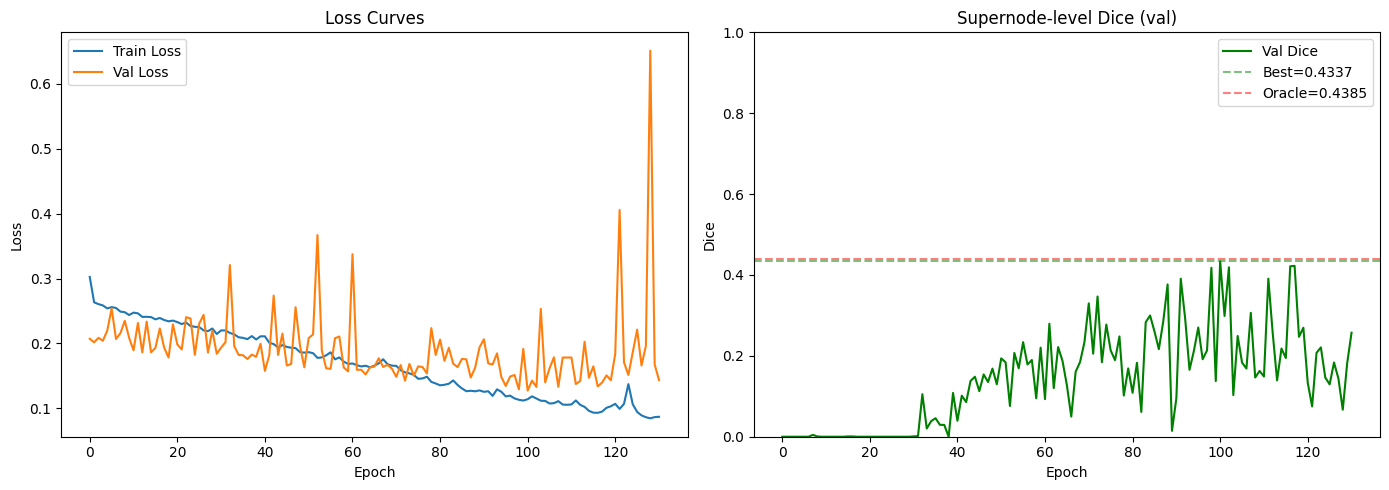

In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Loss Curves")

ax2.plot(history["val_dice"], label="Val Dice", color="green")
ax2.axhline(y=best_dice, color="green", linestyle="--", alpha=0.5, label=f"Best={best_dice:.4f}")
ax2.axhline(y=mean_oracle, color="red", linestyle="--", alpha=0.5, label=f"Oracle={mean_oracle:.4f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice")
ax2.legend()
ax2.set_title("Supernode-level Dice (val)")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Voxel-Level Prediction & Dice Scores

Lift supernode predictions back to voxels via LUT (O(N)):
1. GINE outputs per-supernode logits → argmax → tumor/background per supernode
2. Build lookup table: supernode_id → is_tumor
3. `pred_mask[voxel] = LUT[labels[voxel]]`
4. Compare `pred_mask` with GT → voxel-level Dice

Paper target: **0.891 ± 0.007** on LiTS tumor.

In [10]:
model.eval()
dice_scores = []

for i, (gm, vol, seg, cid, data, nf) in enumerate(
        zip(minors, volumes, segs, case_ids, pyg_graphs, all_node_feats)):
    
    with torch.no_grad():
        data_dev = data.clone().to(device)
        logits = model(data_dev)
        preds = logits.argmax(dim=1).cpu().numpy()
    
    # LUT lift: O(N) — map supernode predictions to voxels
    sids = sorted(nf.keys())
    max_label = int(gm["labels"].max())
    tumor_lut = np.zeros(max_label + 1, dtype=np.int32)
    for idx, sid in enumerate(sids):
        if preds[idx] == 1:
            tumor_lut[sid] = 2
    pred_mask = tumor_lut[gm["labels"]]
    
    gt_tumor = (seg == 2)
    pred_tumor = (pred_mask == 2)
    
    if gt_tumor.sum() == 0:
        dice = 1.0 if pred_tumor.sum() == 0 else 0.0
    else:
        inter = (gt_tumor & pred_tumor).sum()
        dice = float(2 * inter / (gt_tumor.sum() + pred_tumor.sum() + 1e-8))
    
    recall = float((gt_tumor & pred_tumor).sum() / (gt_tumor.sum() + 1e-8))
    precision = float((gt_tumor & pred_tumor).sum() / (pred_tumor.sum() + 1e-8)) if pred_tumor.sum() > 0 else 0
    
    split = "train" if i < n_train_total else ("val" if i < n_train_total + n_val_total else "test")
    dice_scores.append({
        "case_id": cid, "dice": dice, "recall": recall, "precision": precision,
        "gt_voxels": int(gt_tumor.sum()), "pred_voxels": int(pred_tumor.sum()), "split": split,
    })
    print(f"  {cid} [{split}]: Dice={dice:.4f}  Recall={recall:.4f}  "
          f"Precision={precision:.4f}  (GT={gt_tumor.sum():,} → Pred={pred_tumor.sum():,})")

# Summary per split
for split in ["train", "val", "test"]:
    scores = [d["dice"] for d in dice_scores if d["split"] == split]
    if scores:
        print(f"\n{split.upper()}: mean Dice = {np.mean(scores):.4f} ± {np.std(scores):.4f}  (n={len(scores)})")

print(f"\nPaper target (LiTS tumor): 0.891 ± 0.007")

  lits_volume_0 [train]: Dice=0.0000  Recall=0.0000  Precision=0.0000  (GT=704 → Pred=0)
  lits_volume_3 [train]: Dice=0.0007  Recall=0.2569  Precision=0.0004  (GT=728 → Pred=521,395)
  lits_volume_4 [train]: Dice=0.1199  Recall=0.1365  Precision=0.1069  (GT=384,871 → Pred=491,531)
  lits_volume_5 [train]: Dice=0.0000  Recall=0.0000  Precision=0.0000  (GT=148 → Pred=0)
  lits_volume_6 [train]: Dice=0.1202  Recall=0.1041  Precision=0.1421  (GT=8,327 → Pred=6,100)
  lits_volume_7 [train]: Dice=0.0342  Recall=0.5160  Precision=0.0177  (GT=8,467 → Pred=246,737)
  lits_volume_8 [train]: Dice=0.0000  Recall=0.0000  Precision=0.0000  (GT=5,472 → Pred=0)
  lits_volume_9 [train]: Dice=0.0000  Recall=0.0000  Precision=0.0000  (GT=5,832 → Pred=0)
  lits_volume_10 [train]: Dice=0.0375  Recall=0.6753  Precision=0.0193  (GT=6,391 → Pred=224,068)
  lits_volume_11 [train]: Dice=0.0069  Recall=0.6976  Precision=0.0035  (GT=2,831 → Pred=565,693)
  lits_volume_12 [train]: Dice=0.0000  Recall=0.0000  Prec

## 8. Visualize Predictions vs GT

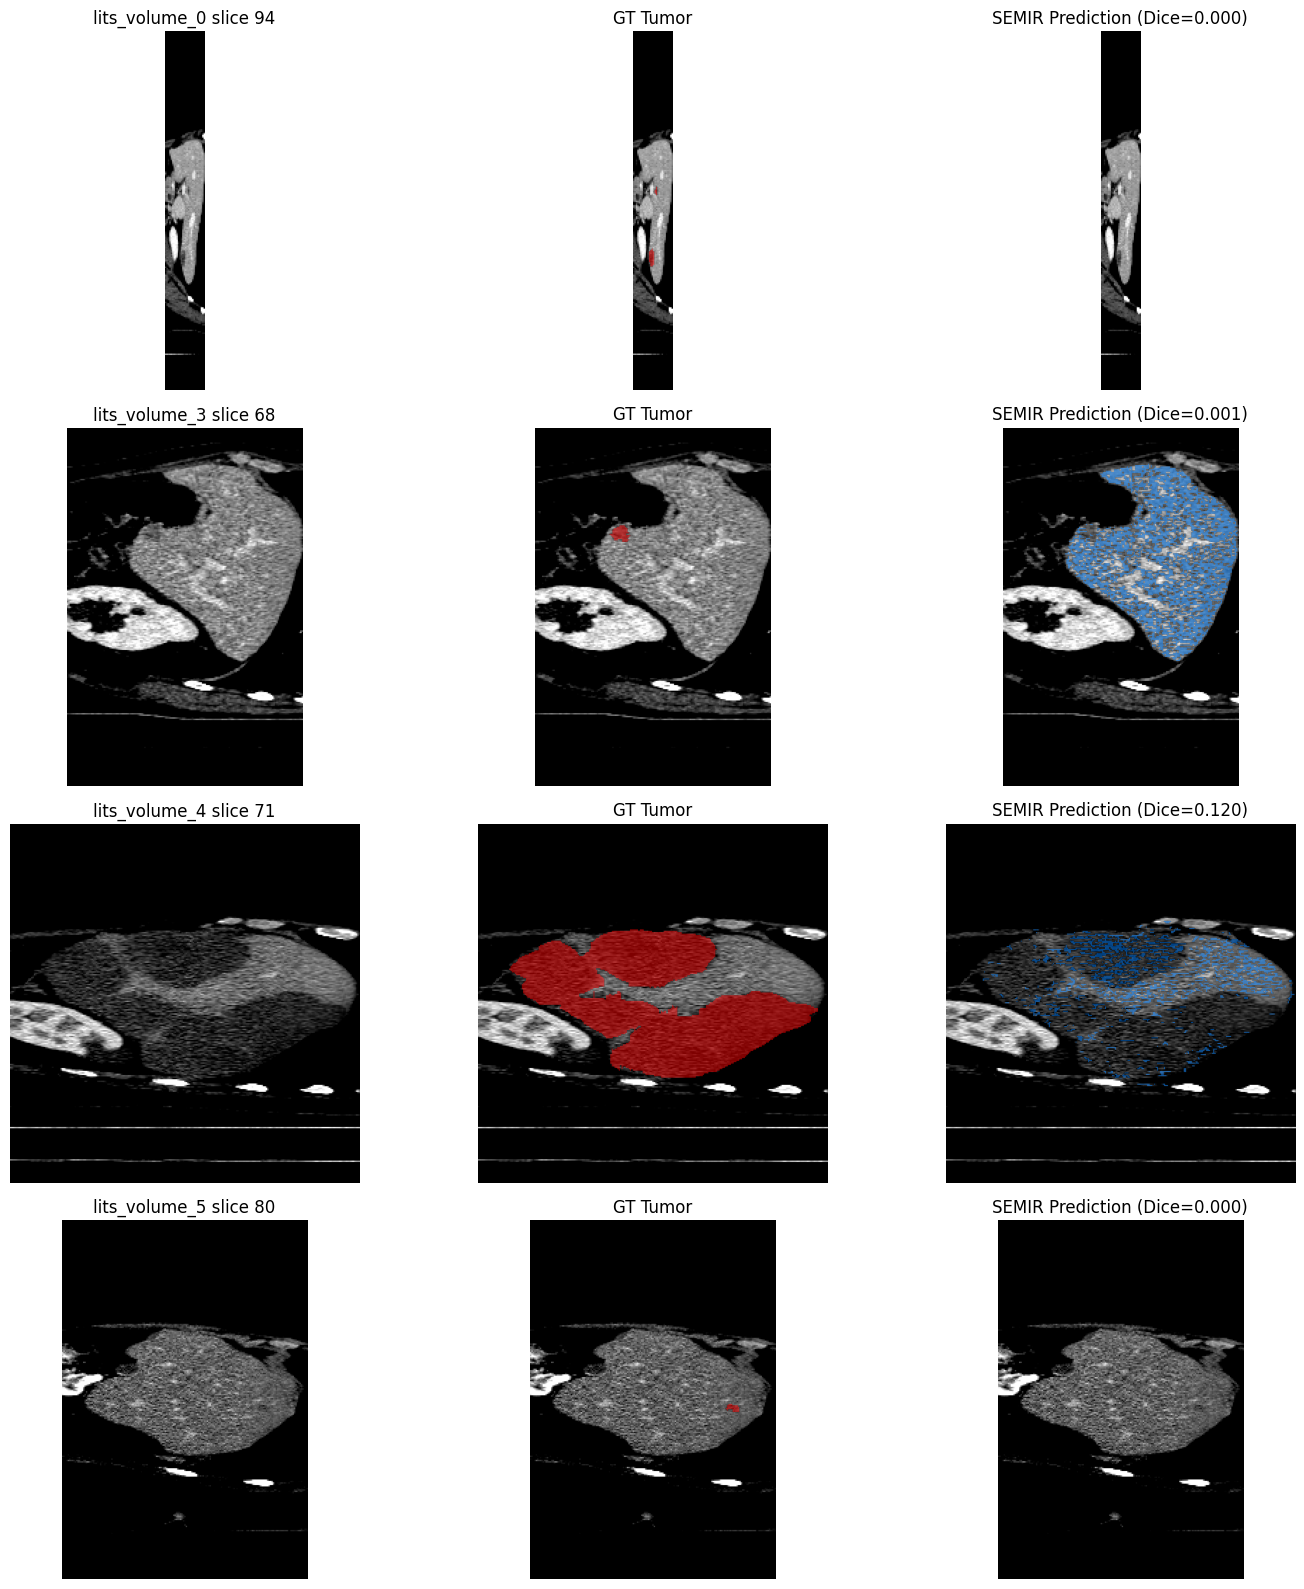

In [11]:
# Visualize predictions for a few cases
n_show = min(4, len(volumes))
fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row in range(n_show):
    gm = minors[row]
    seg = segs[row]
    vol = volumes[row]
    nf = all_node_feats[row]
    data = pyg_graphs[row]
    
    # Get prediction
    with torch.no_grad():
        data_dev = data.clone().to(device)
        logits = model(data_dev)
        preds = logits.argmax(dim=1).cpu().numpy()
    
    sids = sorted(nf.keys())
    max_label = int(gm["labels"].max())
    tumor_lut = np.zeros(max_label + 1, dtype=np.int32)
    for idx, sid in enumerate(sids):
        if preds[idx] == 1:
            tumor_lut[sid] = 1
    pred_mask = tumor_lut[gm["labels"]]
    
    # Find best slice
    tumor_per_slice = (seg == 2).sum(axis=(0, 1))
    sl = int(np.argmax(tumor_per_slice))
    
    # CT
    axes[row, 0].imshow(vol[:, :, sl].T, cmap="gray", origin="lower")
    axes[row, 0].set_title(f"{case_ids[row]} slice {sl}")
    
    # GT
    gt_overlay = np.zeros((*vol[:, :, sl].T.shape, 4))
    gt_overlay[seg[:, :, sl].T == 2] = [1, 0, 0, 0.5]
    axes[row, 1].imshow(vol[:, :, sl].T, cmap="gray", origin="lower")
    axes[row, 1].imshow(gt_overlay, origin="lower")
    axes[row, 1].set_title(f"GT Tumor")
    
    # Prediction
    pred_overlay = np.zeros((*vol[:, :, sl].T.shape, 4))
    pred_overlay[pred_mask[:, :, sl].T == 1] = [0, 0.5, 1, 0.5]
    axes[row, 2].imshow(vol[:, :, sl].T, cmap="gray", origin="lower")
    axes[row, 2].imshow(pred_overlay, origin="lower")
    d = dice_scores[row]["dice"]
    axes[row, 2].set_title(f"SEMIR Prediction (Dice={d:.3f})")
    
    for c in range(3):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()

## 9. Summary & Diagnostics

Key numbers to check:
- **Oracle Dice** — ceiling from graph minor quality. If low, contraction/deletion is the bottleneck.
- **GINE val Dice** — supernode-level classifier accuracy. If oracle is high but this is low, GINE needs work.
- **Voxel Dice** — end-to-end result. Gap vs paper target (0.891) tells us how far off we are.
- **Edge count** — if most graphs have 0 edges, GINE has no message passing and is just an MLP on node features.

In [12]:
print("=" * 60)
print("  SEMIR LiTS End-to-End Results")
print("=" * 60)

val_scores = [d["dice"] for d in dice_scores if d["split"] == "val"]
test_scores = [d["dice"] for d in dice_scores if d["split"] == "test"]
all_scores = [d["dice"] for d in dice_scores]

print(f"\n  Graph Minor:")
print(f"    Method:           {minors[0]['stats']['method']}")
print(f"    Params:           psi={PARAMS['psi']}, alpha={PARAMS['alpha']}, beta_min={PARAMS['beta_min']}")
mean_sn = np.mean([m["stats"]["n_supernodes_after_deletion"] for m in minors])
mean_edges = np.mean([len(m["full_adjacency"]) for m in minors])
mean_compress = np.mean([m["stats"]["compression_ratio"] for m in minors])
print(f"    Mean supernodes:  {mean_sn:,.0f}")
print(f"    Mean full edges:  {mean_edges:,.0f}")
print(f"    Mean compression: {mean_compress:,.0f}x")

print(f"\n  Oracle (quality ceiling):")
print(f"    Mean oracle Dice: {mean_oracle:.4f}")

print(f"\n  GINE Classifier:")
print(f"    Best val Dice (supernode-level): {best_dice:.4f}")
print(f"    Epochs trained: {len(history['train_loss'])}")

print(f"\n  Voxel-Level Dice:")
if val_scores:
    print(f"    Val:   {np.mean(val_scores):.4f} +/- {np.std(val_scores):.4f}")
if test_scores:
    print(f"    Test:  {np.mean(test_scores):.4f} +/- {np.std(test_scores):.4f}")
print(f"    All:   {np.mean(all_scores):.4f} +/- {np.std(all_scores):.4f}")
print(f"    Paper: 0.891 +/- 0.007")

print(f"\n  Diagnosis:")
if mean_oracle < 0.7:
    print(f"    [!] Oracle Dice is low ({mean_oracle:.3f}) — graph minor is losing tumor structure.")
    print(f"        Try: adjust psi/beta_min, check HU window, verify C flood-fill.")
elif best_dice < 0.5:
    print(f"    [!] GINE supernode Dice is low ({best_dice:.3f}) — classifier is the bottleneck.")
    print(f"        Try: different architecture, learning rate, loss function, more training data.")
elif np.mean(all_scores) < 0.5:
    print(f"    [!] Voxel Dice is low despite decent GINE — lifting or edge sparsity issue.")
else:
    print(f"    Pipeline is functioning. Gap to paper may be from contraction method difference.")

# Edge sparsity diagnostic
zero_edge_graphs = sum(1 for g in pyg_graphs if g.num_edges == 0)
print(f"\n  Edge sparsity: {zero_edge_graphs}/{len(pyg_graphs)} graphs have 0 edges")

  SEMIR LiTS End-to-End Results

  Graph Minor:
    Method:           c
    Params:           psi=0.06, alpha=0.06, beta_min=10
    Mean supernodes:  16,062
    Mean full edges:  41,702
    Mean compression: 743x

  Oracle (quality ceiling):
    Mean oracle Dice: 0.4385

  GINE Classifier:
    Best val Dice (supernode-level): 0.4337
    Epochs trained: 131

  Voxel-Level Dice:
    Val:   0.1359 +/- 0.3052
    Test:  0.0276 +/- 0.0772
    All:   0.0734 +/- 0.2002
    Paper: 0.891 +/- 0.007

  Diagnosis:
    [!] Oracle Dice is low (0.438) — graph minor is losing tumor structure.
        Try: adjust psi/beta_min, check HU window, verify C flood-fill.

  Edge sparsity: 0/131 graphs have 0 edges


## Source Files Reference

| Module | File | What it does |
|---|---|---|
| Graph minor | `src/semir/graph_minor.py` | Edge contraction (C flood-fill or adaptive watershed), node deletion, edge deletion |
| C backend | `src/semir/semir_minor.c` | Flood-fill with canonical-voxel anchoring (prevents transitive drift) |
| Features | `src/semir/features.py` | 7 node features + 4 edge features, builds PyG Data objects |
| GINE | `src/semir/gine.py` | 3-layer GINEConv classifier + training loop |
| VKG builder | `src/semir/vkg_builder.py` | Converts SEMIR supernodes → VKG JSON (nodes/edges/phenotypes) |
| Grouping | `src/semir/grouping.py` | Aggregates multiple tumor supernodes into physical tumors |

**Paper**: "Efficient Minority-Structure Segmentation via Learned Graph Minors" — `docs/SEMIR-MedicalImages.pdf`